In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import zarr
import os
import sys
import glob

from pathlib import Path

sys.path.append(os.path.abspath(".."))

plt.style.use('../libs/my_style.mplstyle')

cargo_diameter = 0.63

mypass = Path('/mnt/NAS-Ebanaru/sasaki/MTSingleBeads')
mypass = Path('/Volumes/data/Sasaki/MTsingleBeads')
subdir = "beads06um"


input_dir = mypass / subdir

def op_plot(input_dir, cargo_diameter=None):
    output = f'global_order_boxplot{cargo_diameter}.svg'
    op_data = []

    labels = []
    # データの読み込み
    for exp_subpath in sorted(glob.glob(str(input_dir/ "*" / "*"))):
        exp_subpath = Path(exp_subpath)
        target_path =  exp_subpath / "MTs_order_parameter.zarr"
        
        if target_path.exists():
            try:
                op_zarr = zarr.open(str(target_path), mode='r')
                op = op_zarr[:]
                
                # NaNなどの無効な値を除外して1次元配列にする
                op = np.array(op).flatten()
                op = op[~np.isnan(op)]
                op_data.append(op)
                
                # ラベルに実験のサブパスを使用
                labels.append(exp_subpath.name)
                
                num = len(op)
                op_mean = np.mean(op) if num > 0 else np.nan
                op_sem = np.std(op, ddof=1)/np.sqrt(num) if num > 1 else 0
                print(f"exp{i}: Mean = {op_mean:.4f}, SEM = {op_sem:.4f}, N = {num}")
                print(target_path)

                i+=1
                
            except Exception as e:
                print(f"Error loading {target_path}: {e}")
        #else:
            #print(f"Warning: {target_path} does not exist.")

        # 箱ひげ図の作成
    if op_data:
        fig, ax = plt.subplots()
        
        # ボックスプロットを描画
        bp = ax.boxplot(op_data, labels=labels, patch_artist=True, whis = 1.5)
        
        # 見やすくするために色を付ける（オプション）
        for box in bp['boxes']:
            box.set(facecolor='#88CCEE', alpha=0.6)

        ax.set_ylabel("Nematic Order Parameter $S$")
        ax.set_title(f"Cargo diameter {cargo_diameter} \u03bcm")
        ax.set_ylim(0.0, 1.0)
        plt.xticks(rotation=0, ha='center', fontsize=16)
        plt.tight_layout()
        
        # 画像の保存
        plt.savefig(mypass/"figure"/output, dpi=300)
        print(f"Saved boxplot to {output}")
    else:
        print("No valid data available to plot.")

Error loading /Volumes/data/Sasaki/MTsingleBeads/beads06um/20260716/beads06um/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads06um/20260716/beads06um001/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads06um/20260716/beads06um002/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads06um/20260716/beads06um003/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Saved boxplot to global_order_boxplot0.63.svg


/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_14272/3497470192.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(op_data, labels=labels, patch_artist=True, whis = 1.5)


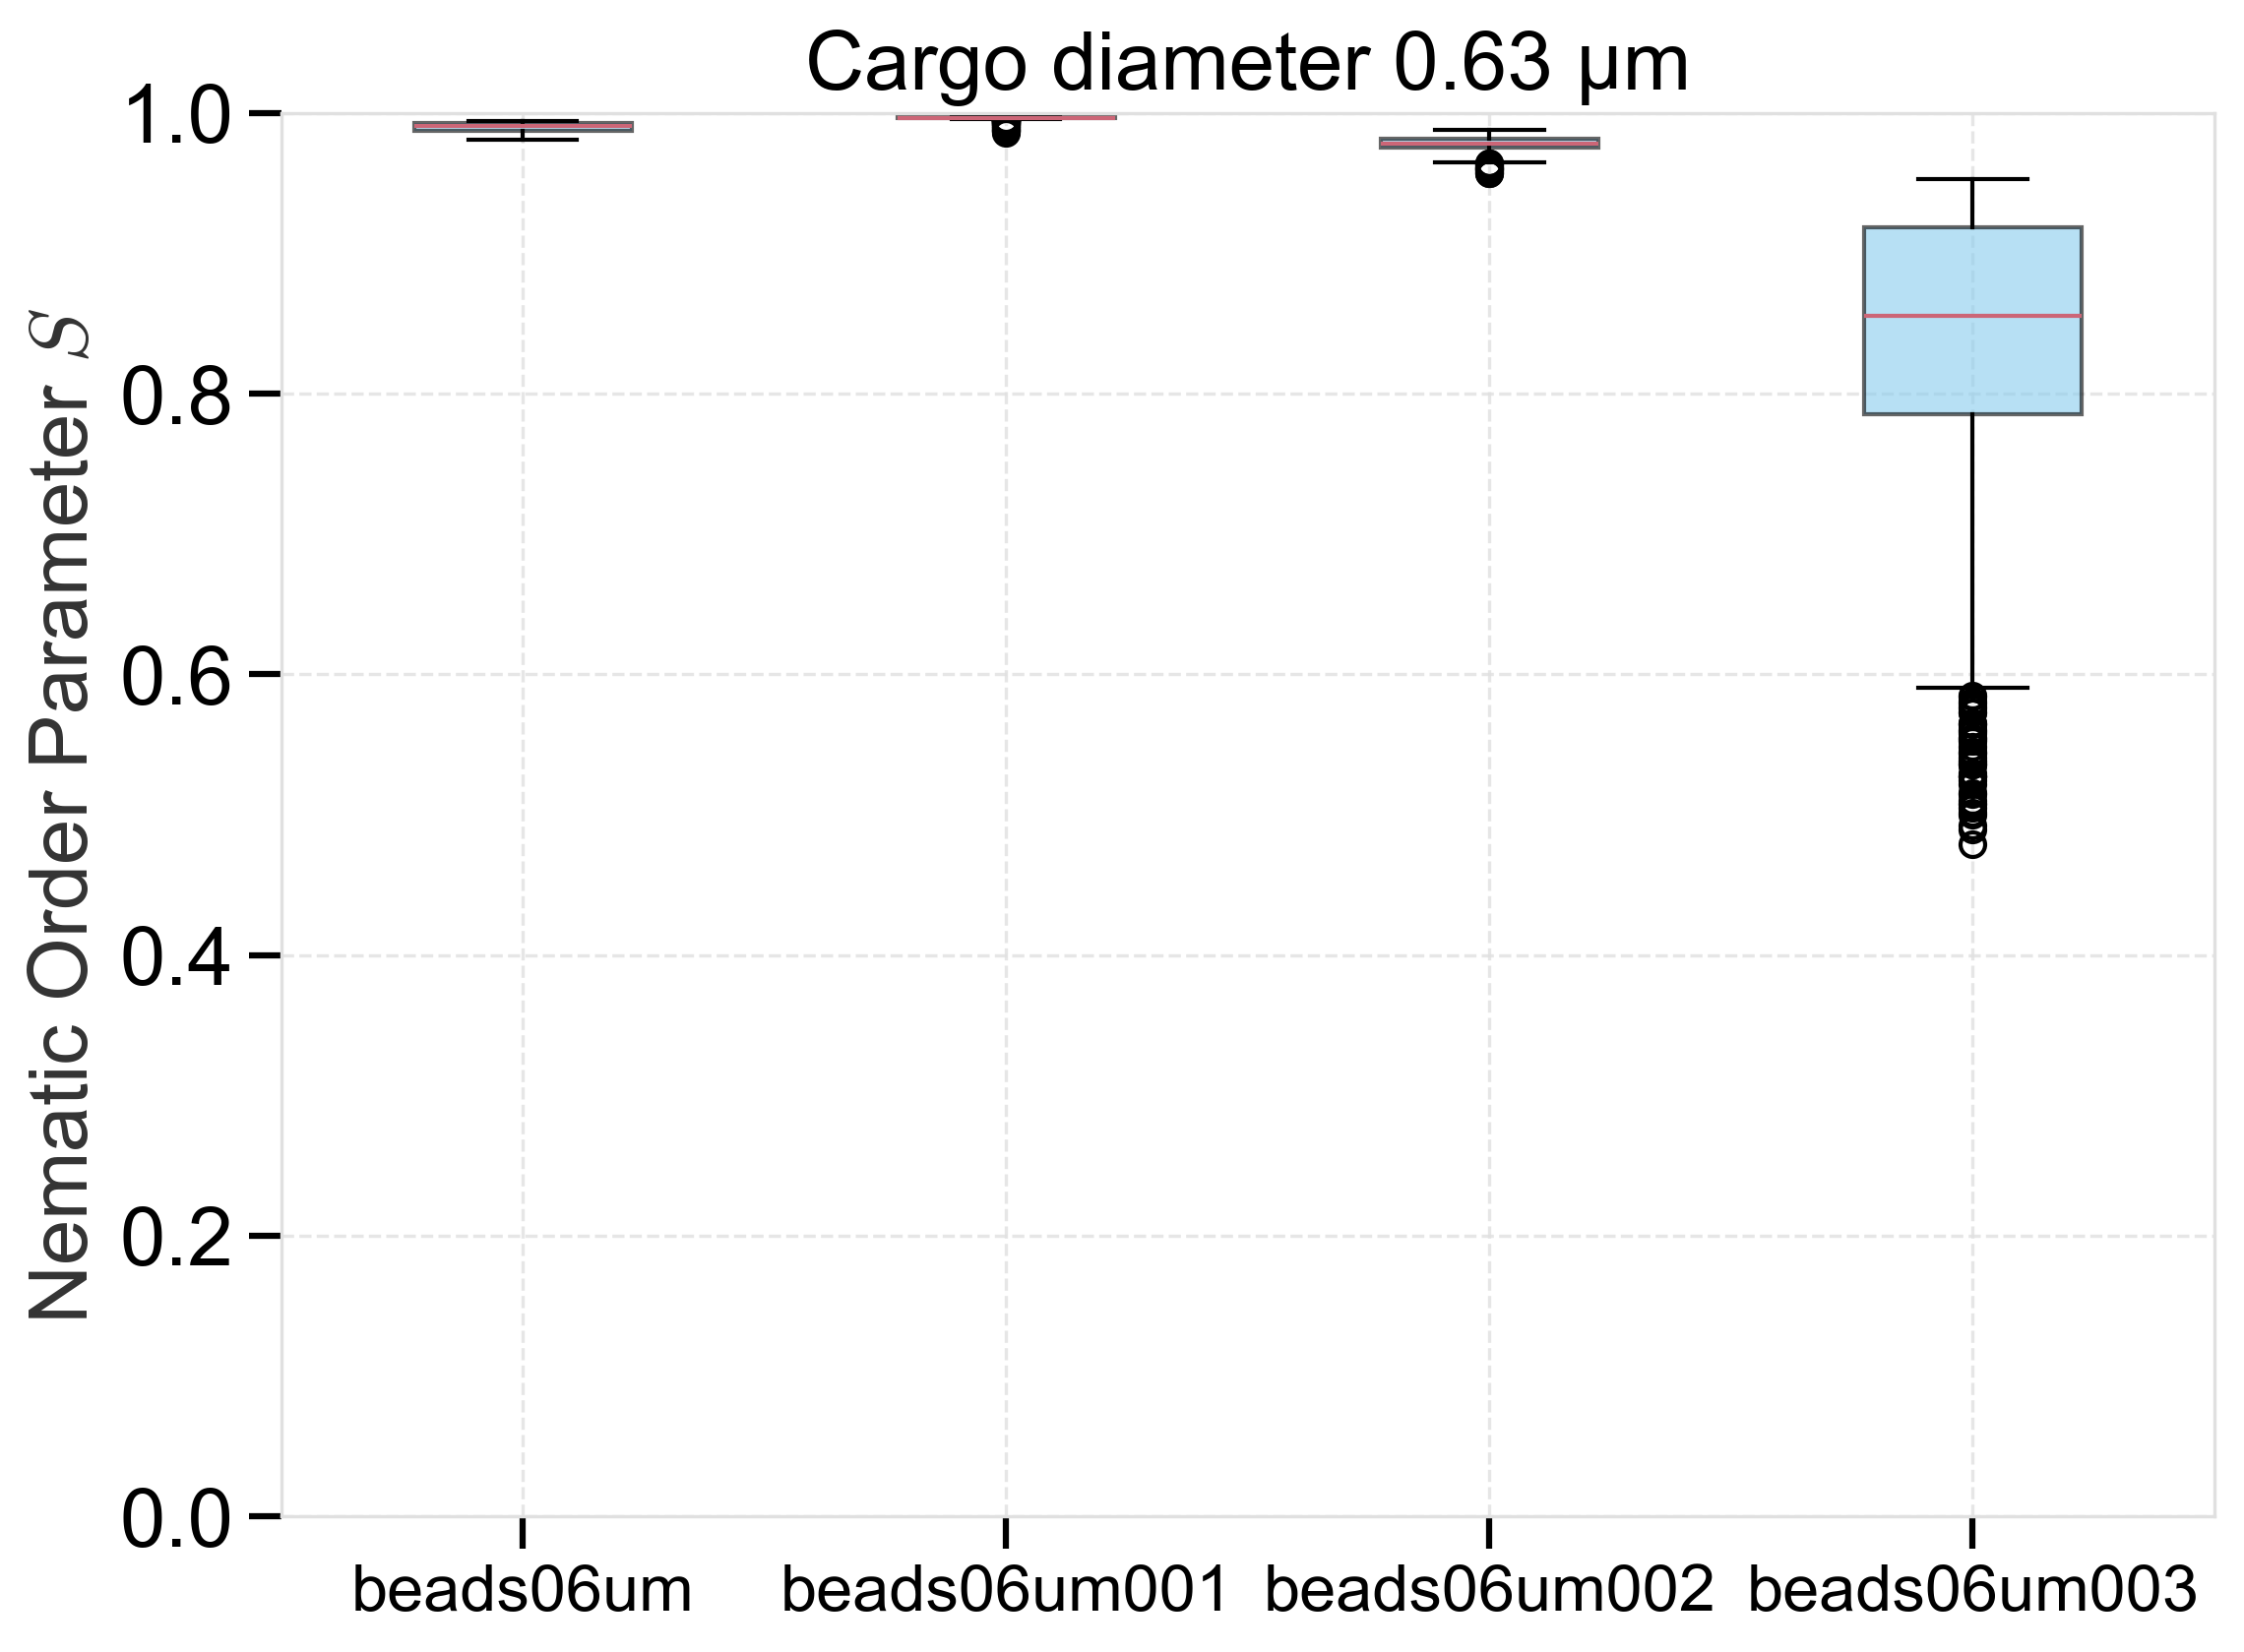

In [3]:
op_plot(mypass/"beads06um", cargo_diameter=0.63)

Error loading /Volumes/data/Sasaki/MTsingleBeads/beads1um/20260717/beads1um001_crop/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads1um/20260717/beads1um002/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads1um/20260717/beads1um003/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads1um/20260717/beads1um_crop/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Saved boxplot to global_order_boxplot1.18.svg


/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_14272/3497470192.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(op_data, labels=labels, patch_artist=True, whis = 1.5)


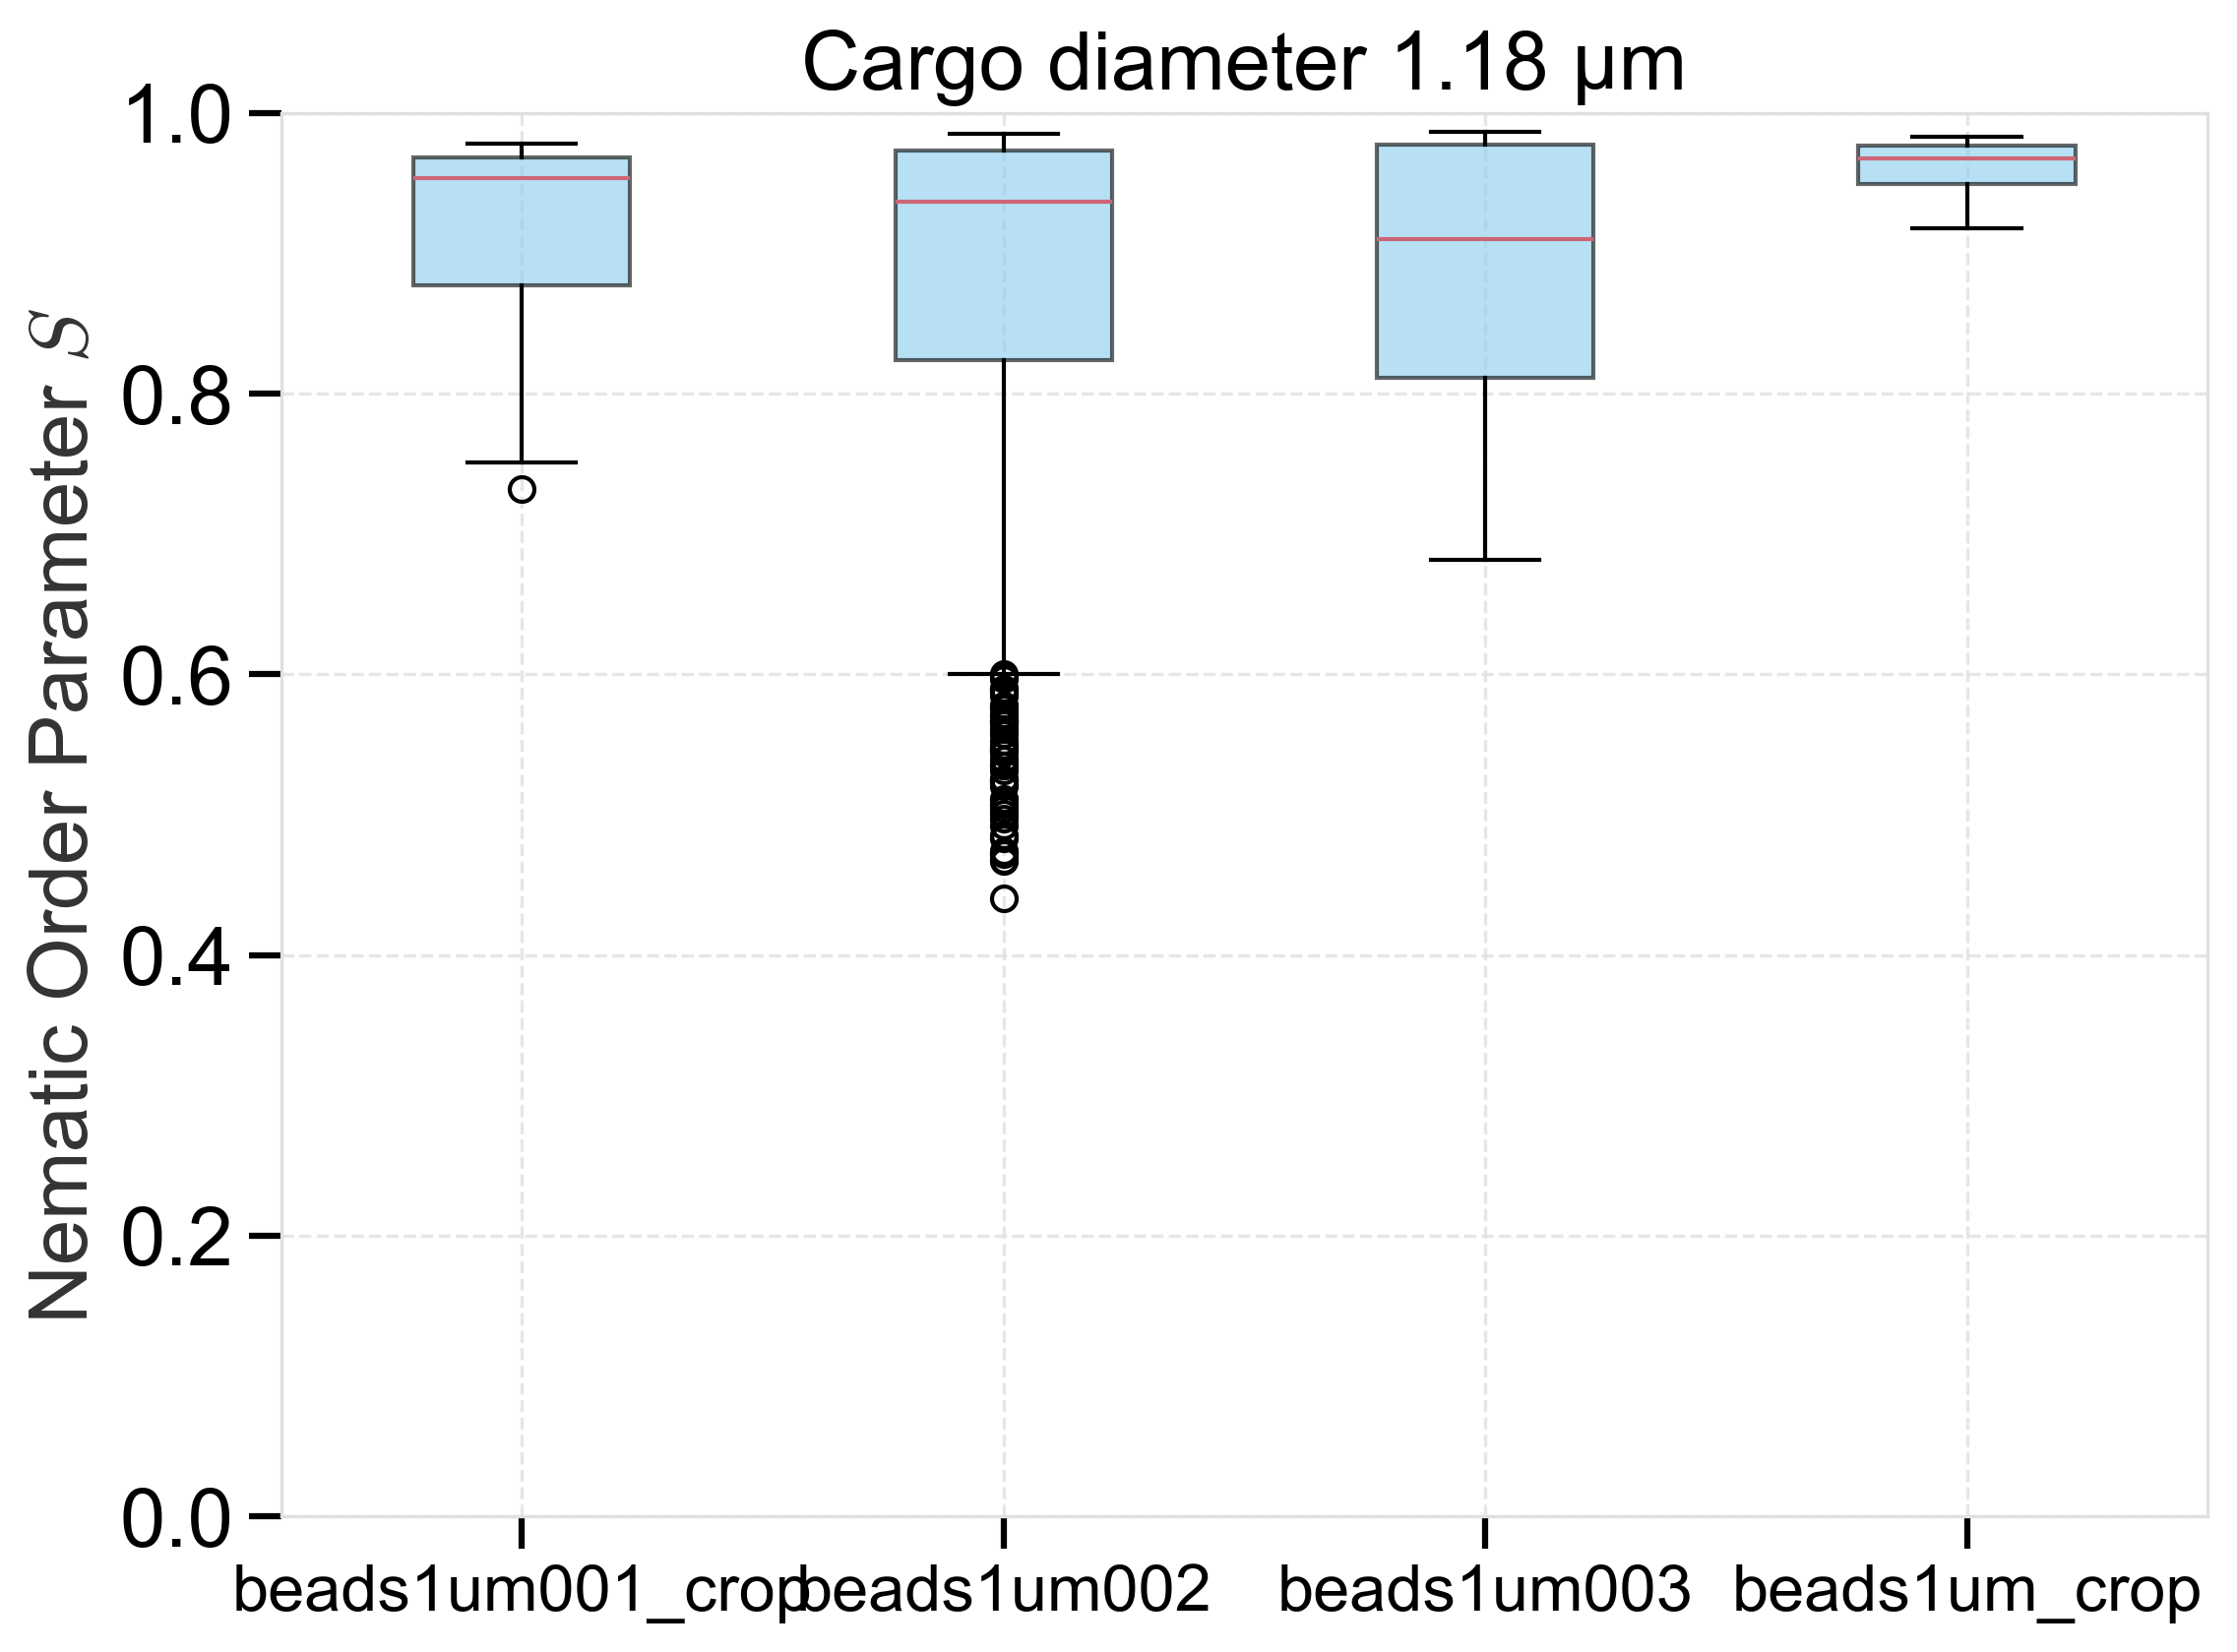

In [4]:
op_plot(mypass/"beads1um", cargo_diameter=1.18)

Error loading /Volumes/data/Sasaki/MTsingleBeads/beads3um/20260708/beads3um/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads3um/20260708/beads3um001/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads3um/20260708/beads3um002/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads3um/20260708/beads3um003/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Saved boxplot to global_order_boxplot3.37.svg


/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_14272/3497470192.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(op_data, labels=labels, patch_artist=True, whis = 1.5)


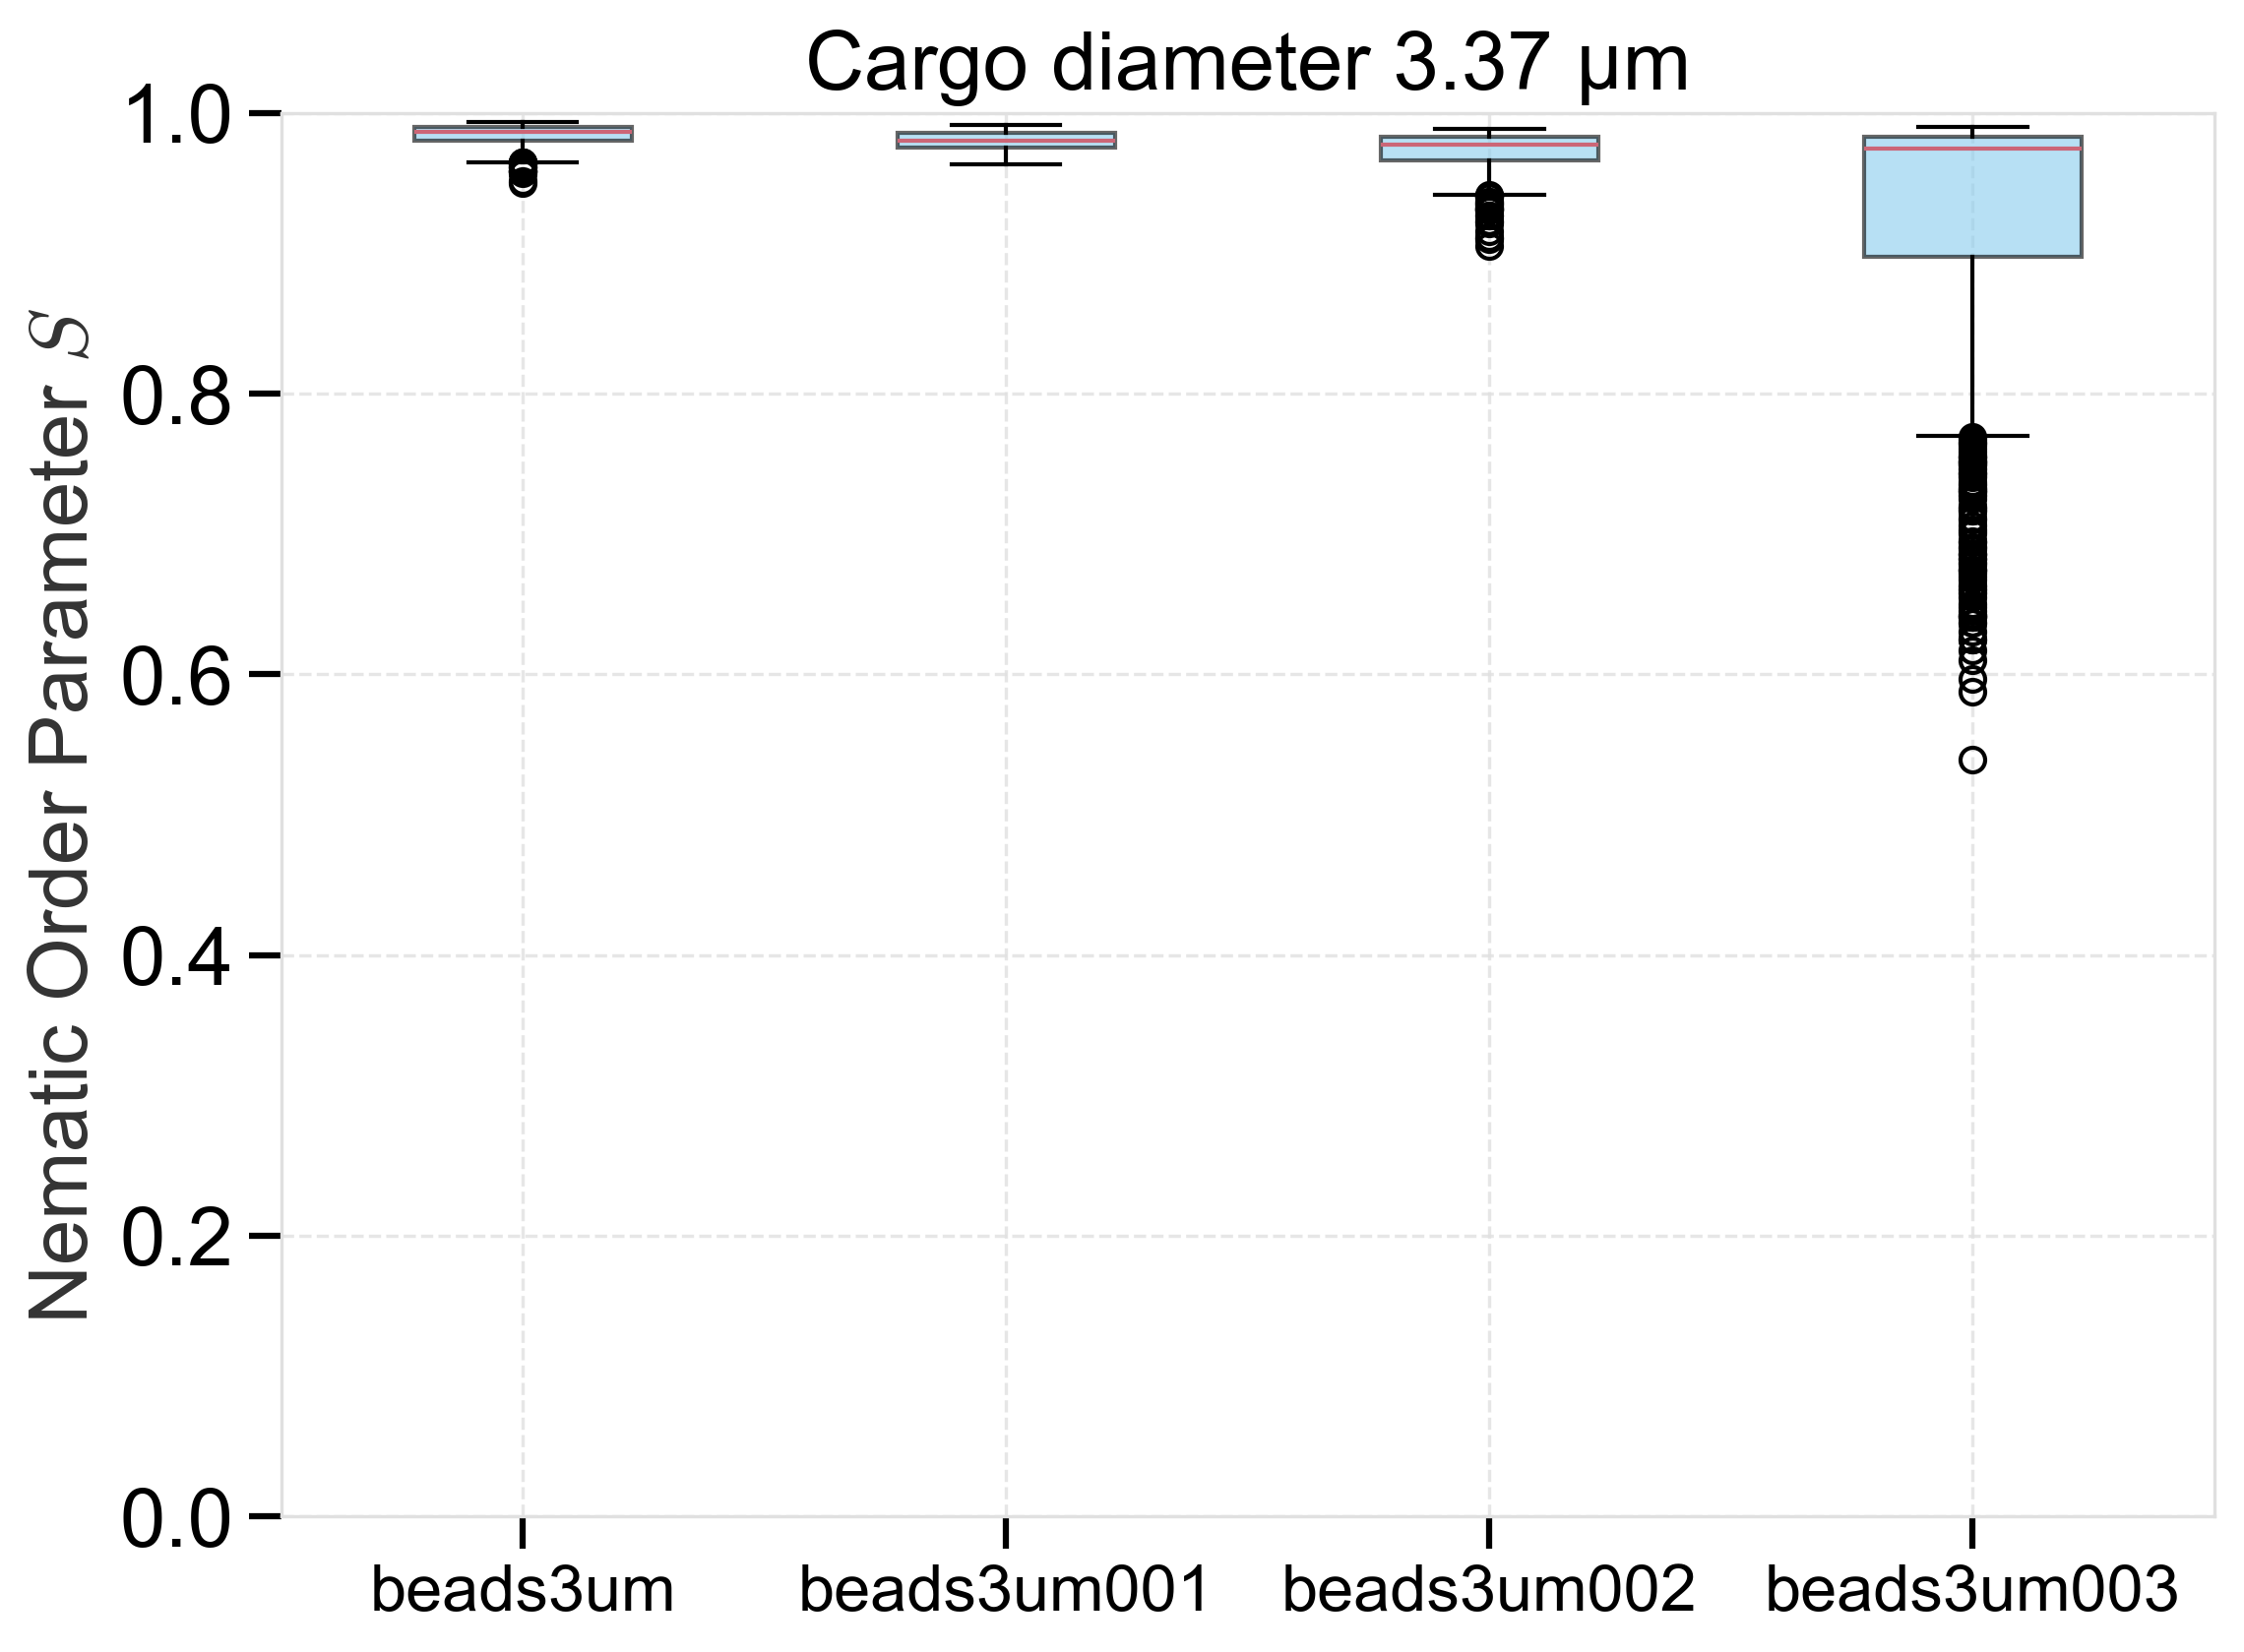

In [5]:
op_plot(mypass/"beads3um", cargo_diameter=3.37)

Error loading /Volumes/data/Sasaki/MTsingleBeads/beads5um/20260715/beads5um/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads5um/20260715/beads5um001/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads5um/20260715/beads5um002/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads5um/20260715/beads5um003/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Saved boxplot to global_order_boxplot5.svg


/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_14272/3497470192.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(op_data, labels=labels, patch_artist=True, whis = 1.5)


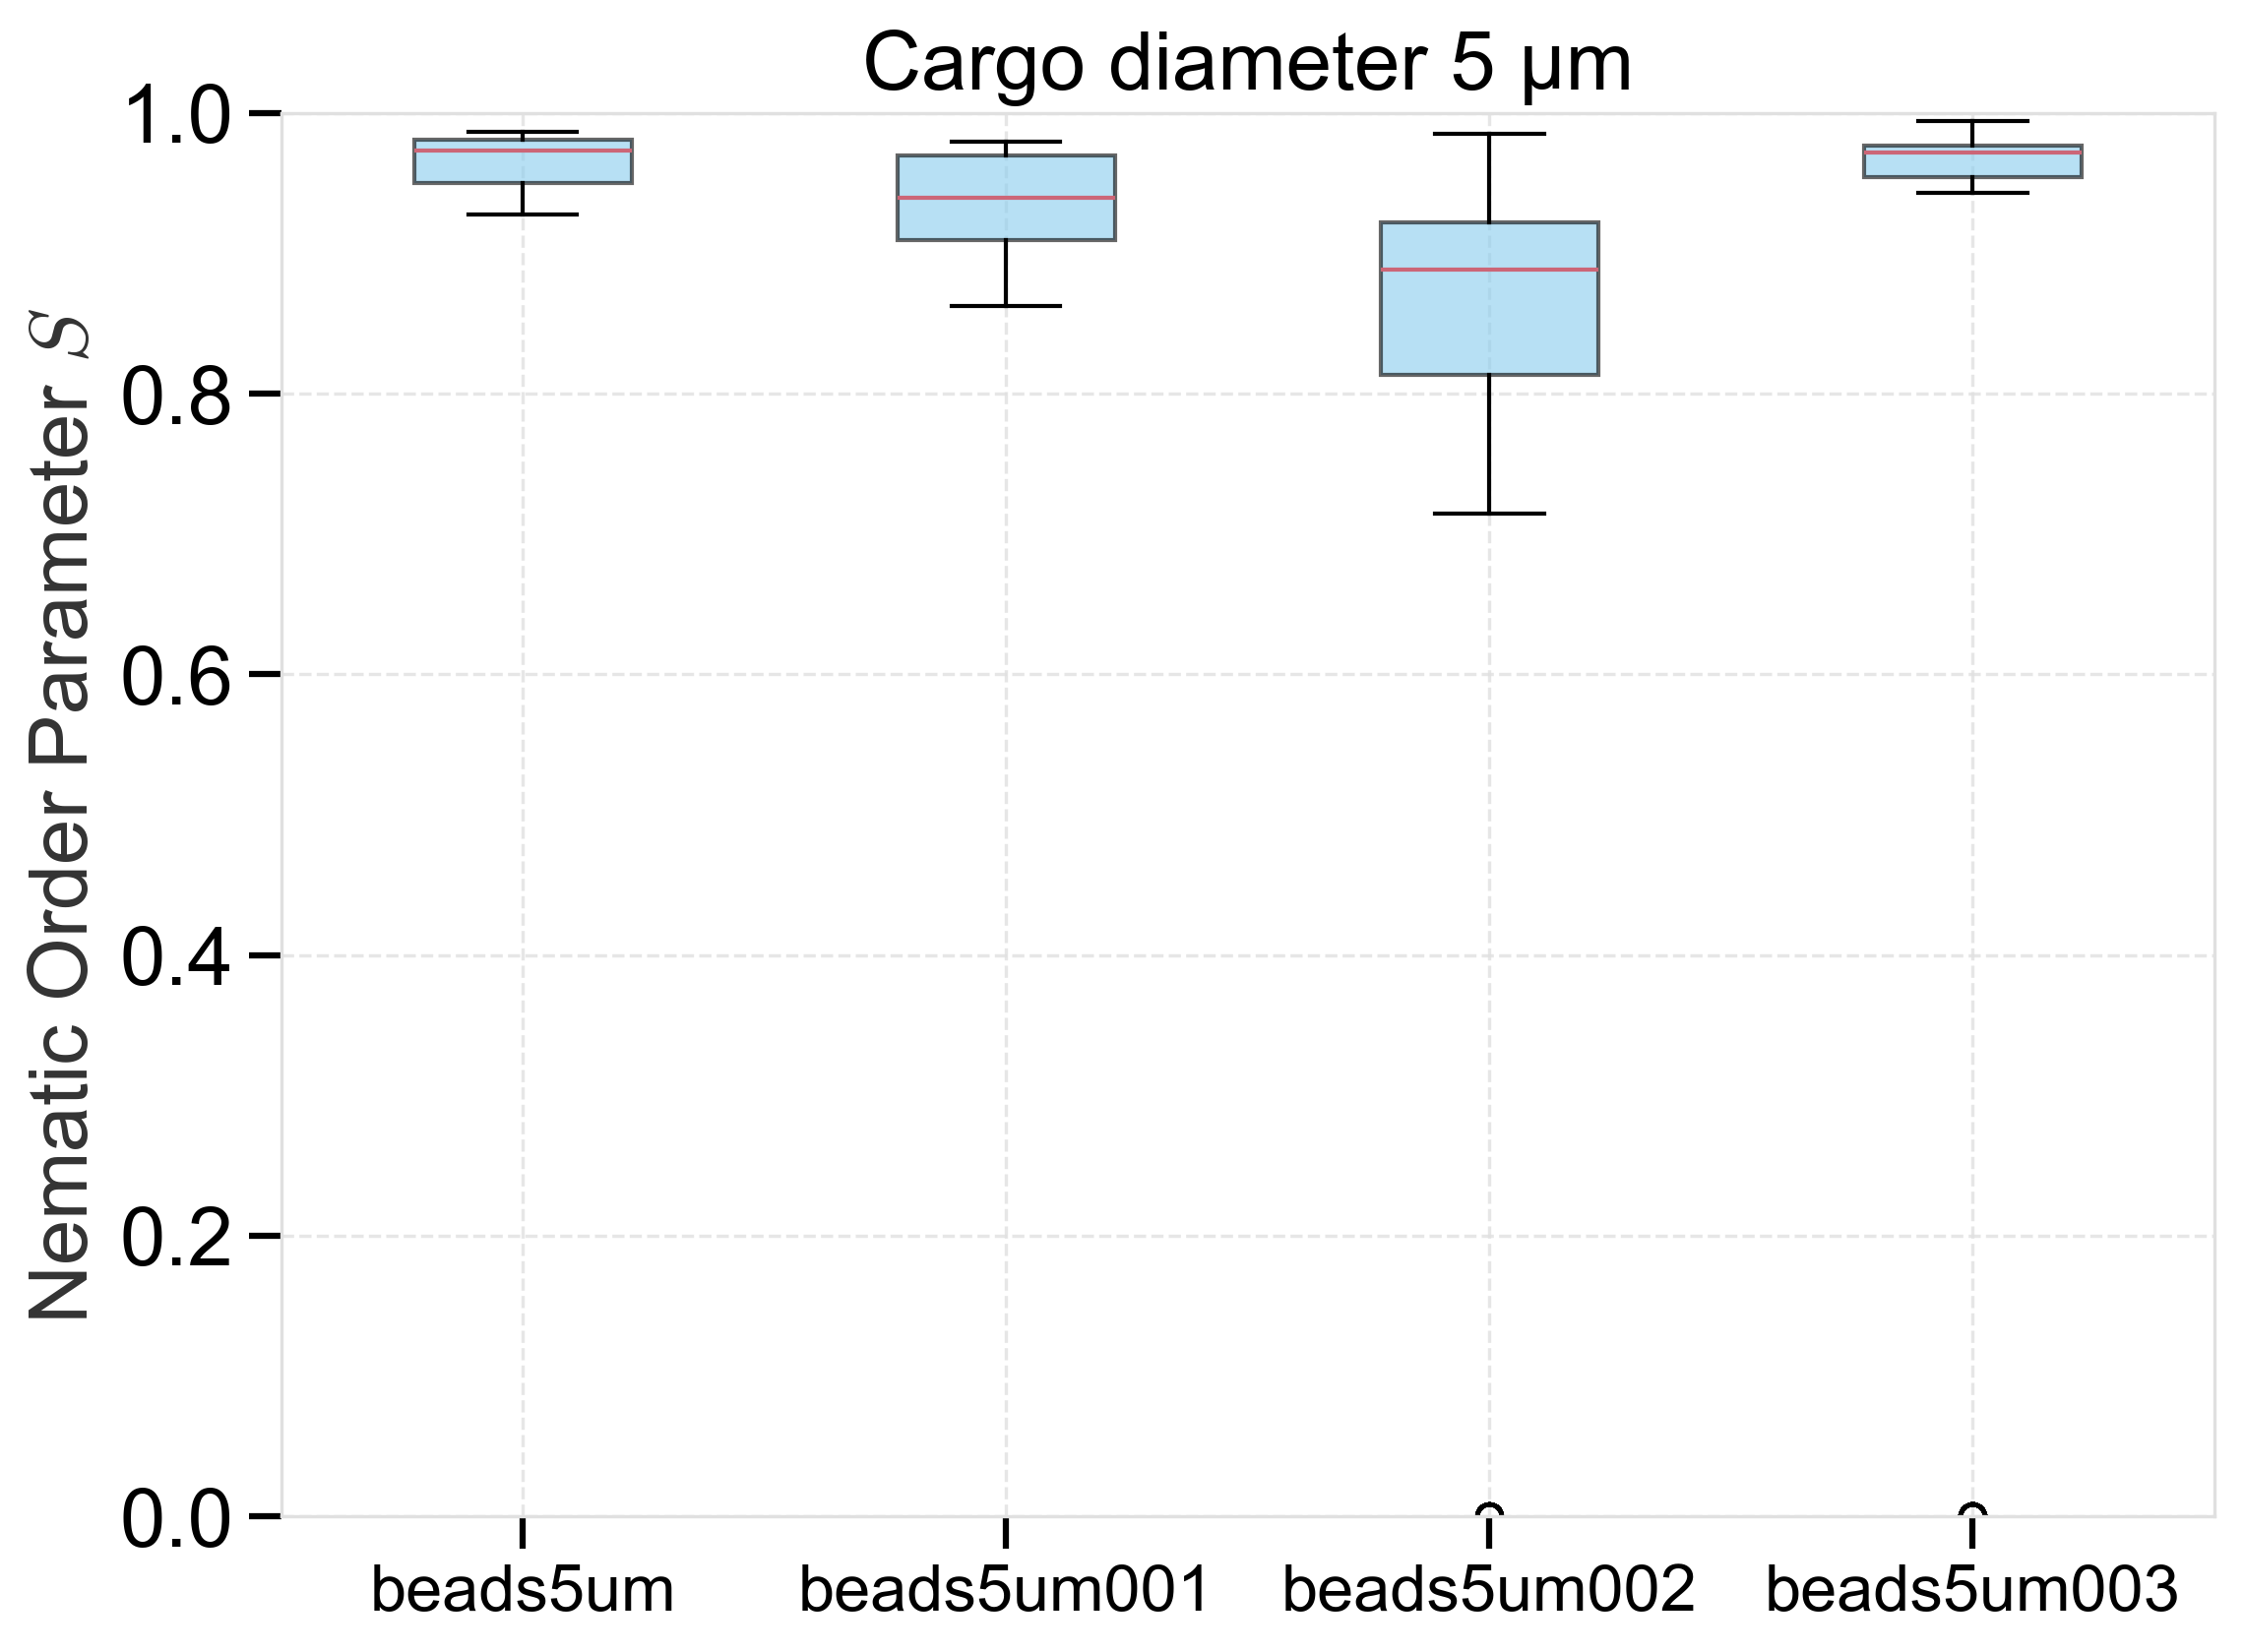

In [6]:
op_plot(mypass/"beads5um", cargo_diameter=5)

Error loading /Volumes/data/Sasaki/MTsingleBeads/beads7um/20260608/beads7um/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads7um/20260608/beads7um002/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads7um/20260608/beads7um003/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Saved boxplot to global_order_boxplot7.24.svg


/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_14272/3497470192.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(op_data, labels=labels, patch_artist=True, whis = 1.5)


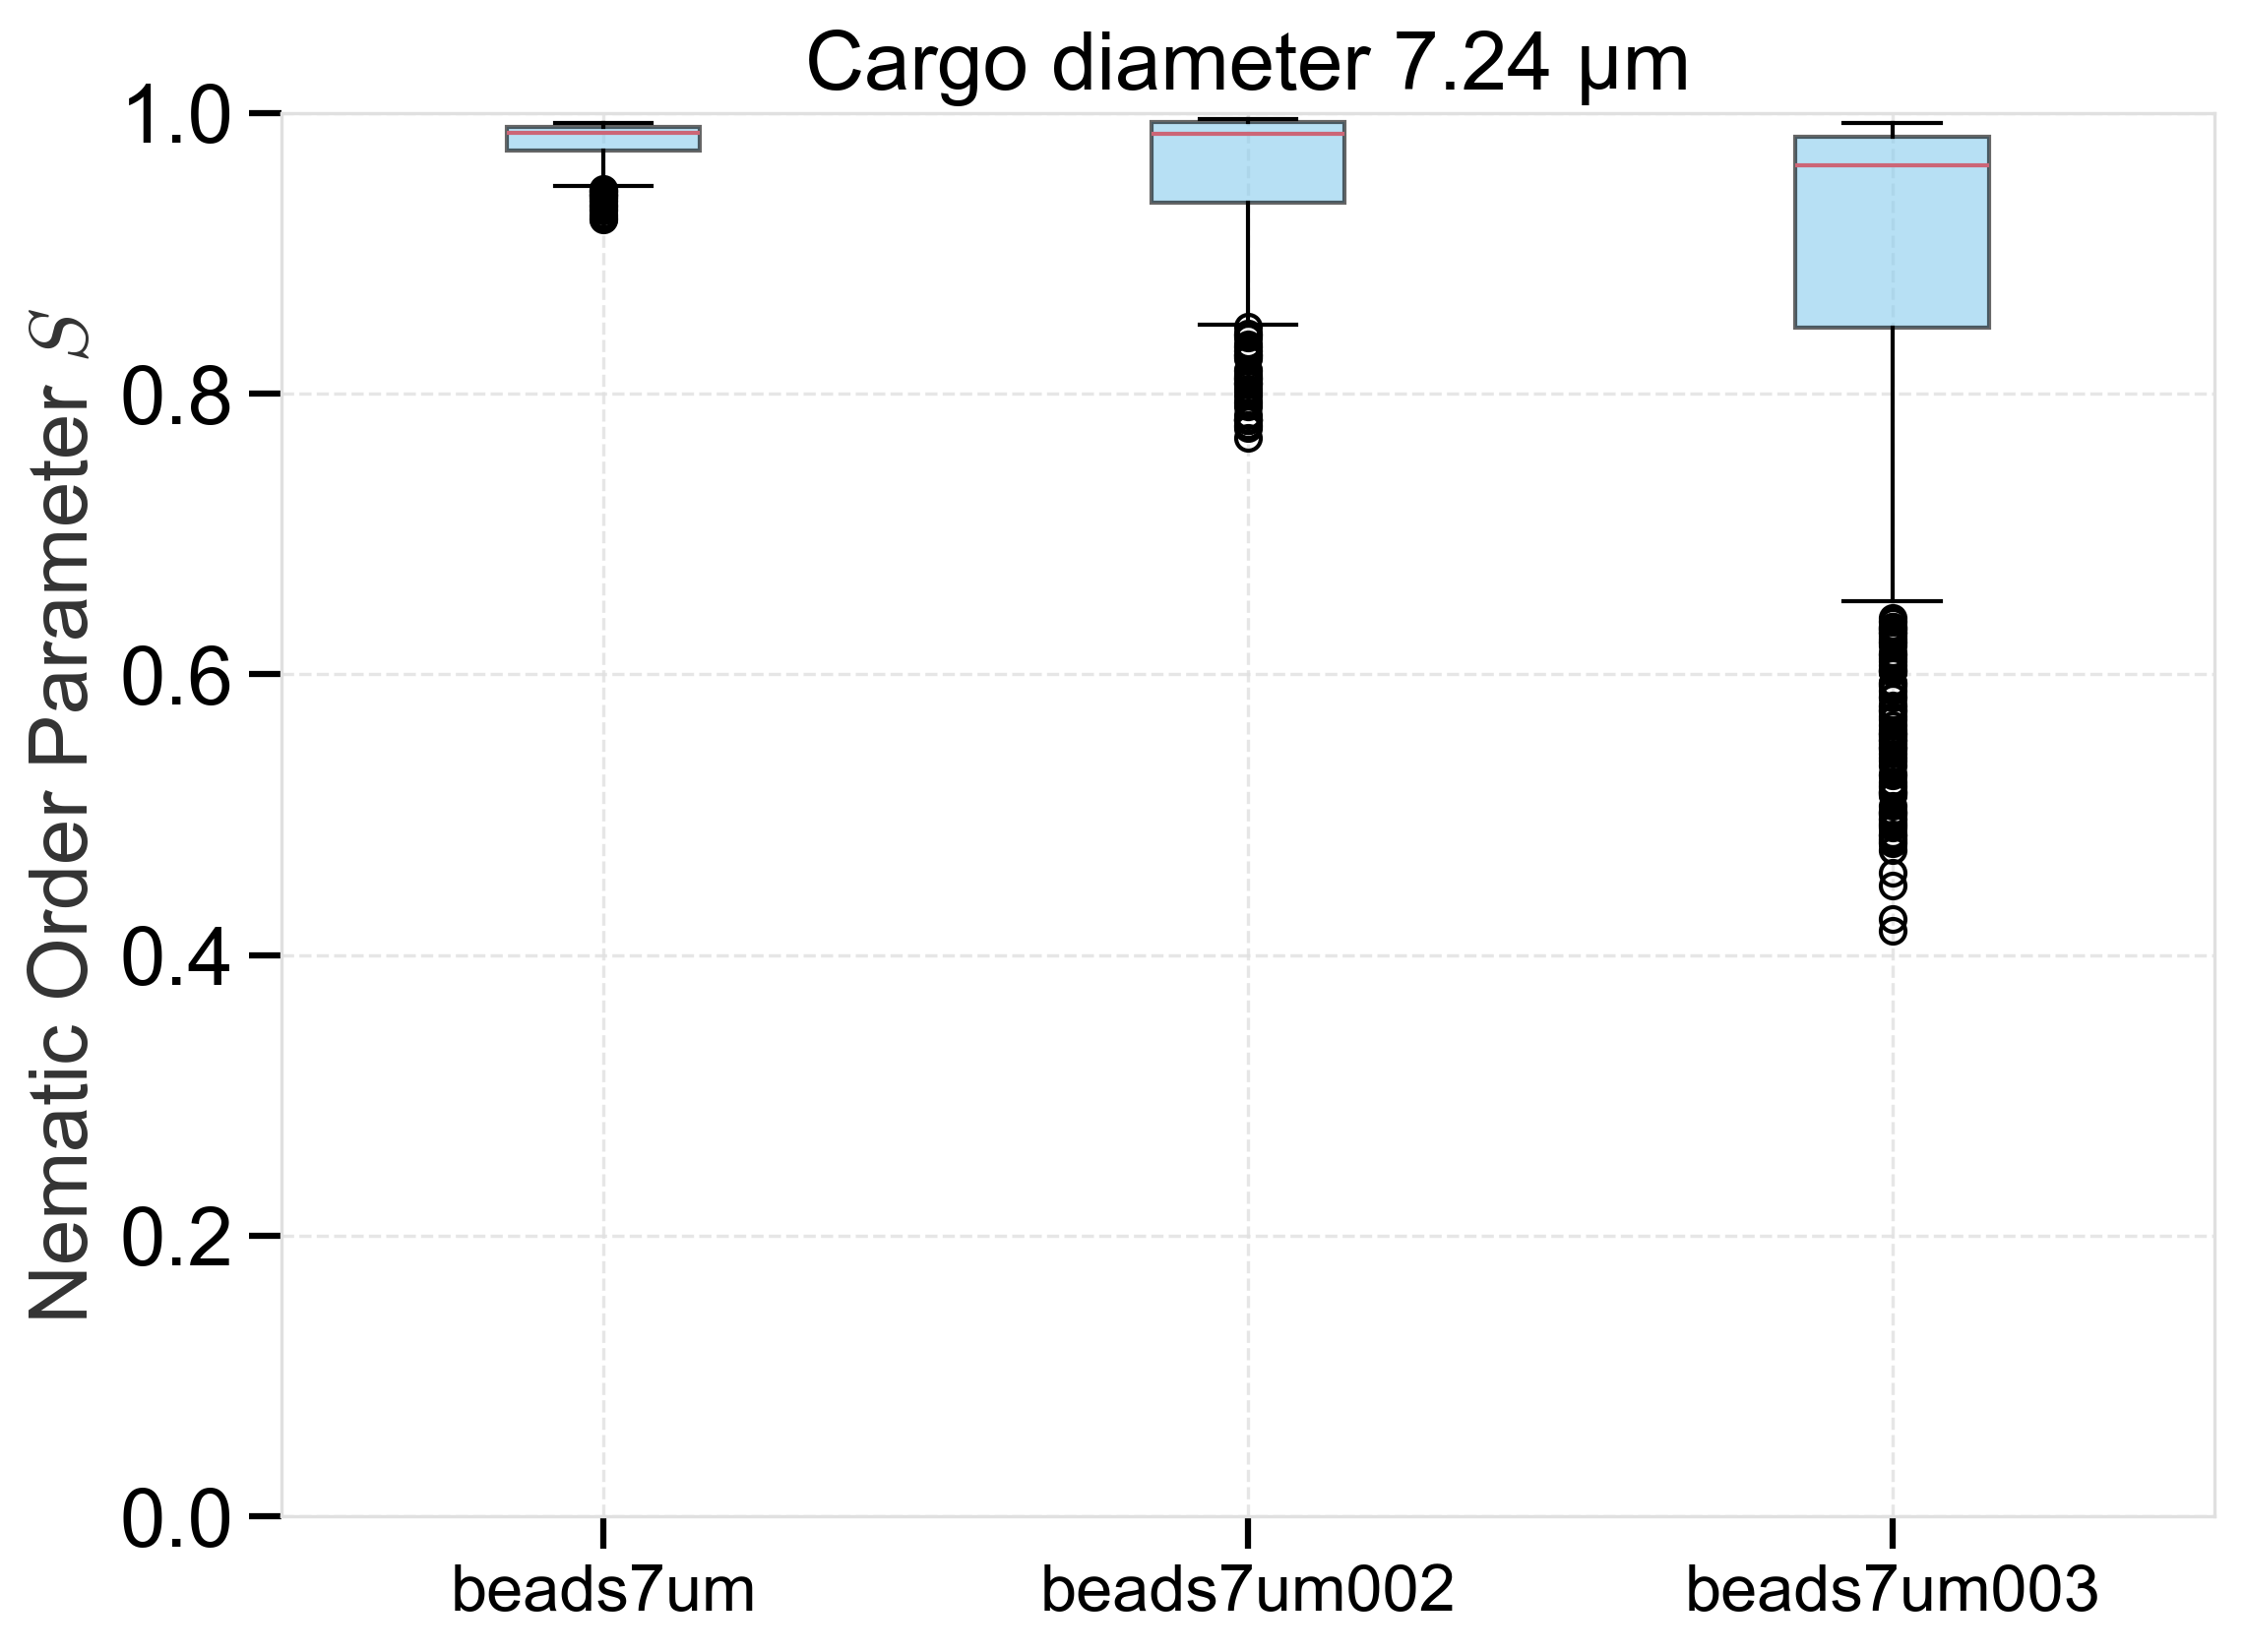

In [7]:
op_plot(mypass/"beads7um", cargo_diameter=7.24)

Error loading /Volumes/data/Sasaki/MTsingleBeads/beads20um/20260723/beads20um001/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads20um/20260723/beads20um002/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Error loading /Volumes/data/Sasaki/MTsingleBeads/beads20um/20260723/beads20um_crop/MTs_order_parameter.zarr: cannot access local variable 'i' where it is not associated with a value
Saved boxplot to global_order_boxplot20.svg


/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_31355/3497470192.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(op_data, labels=labels, patch_artist=True, whis = 1.5)


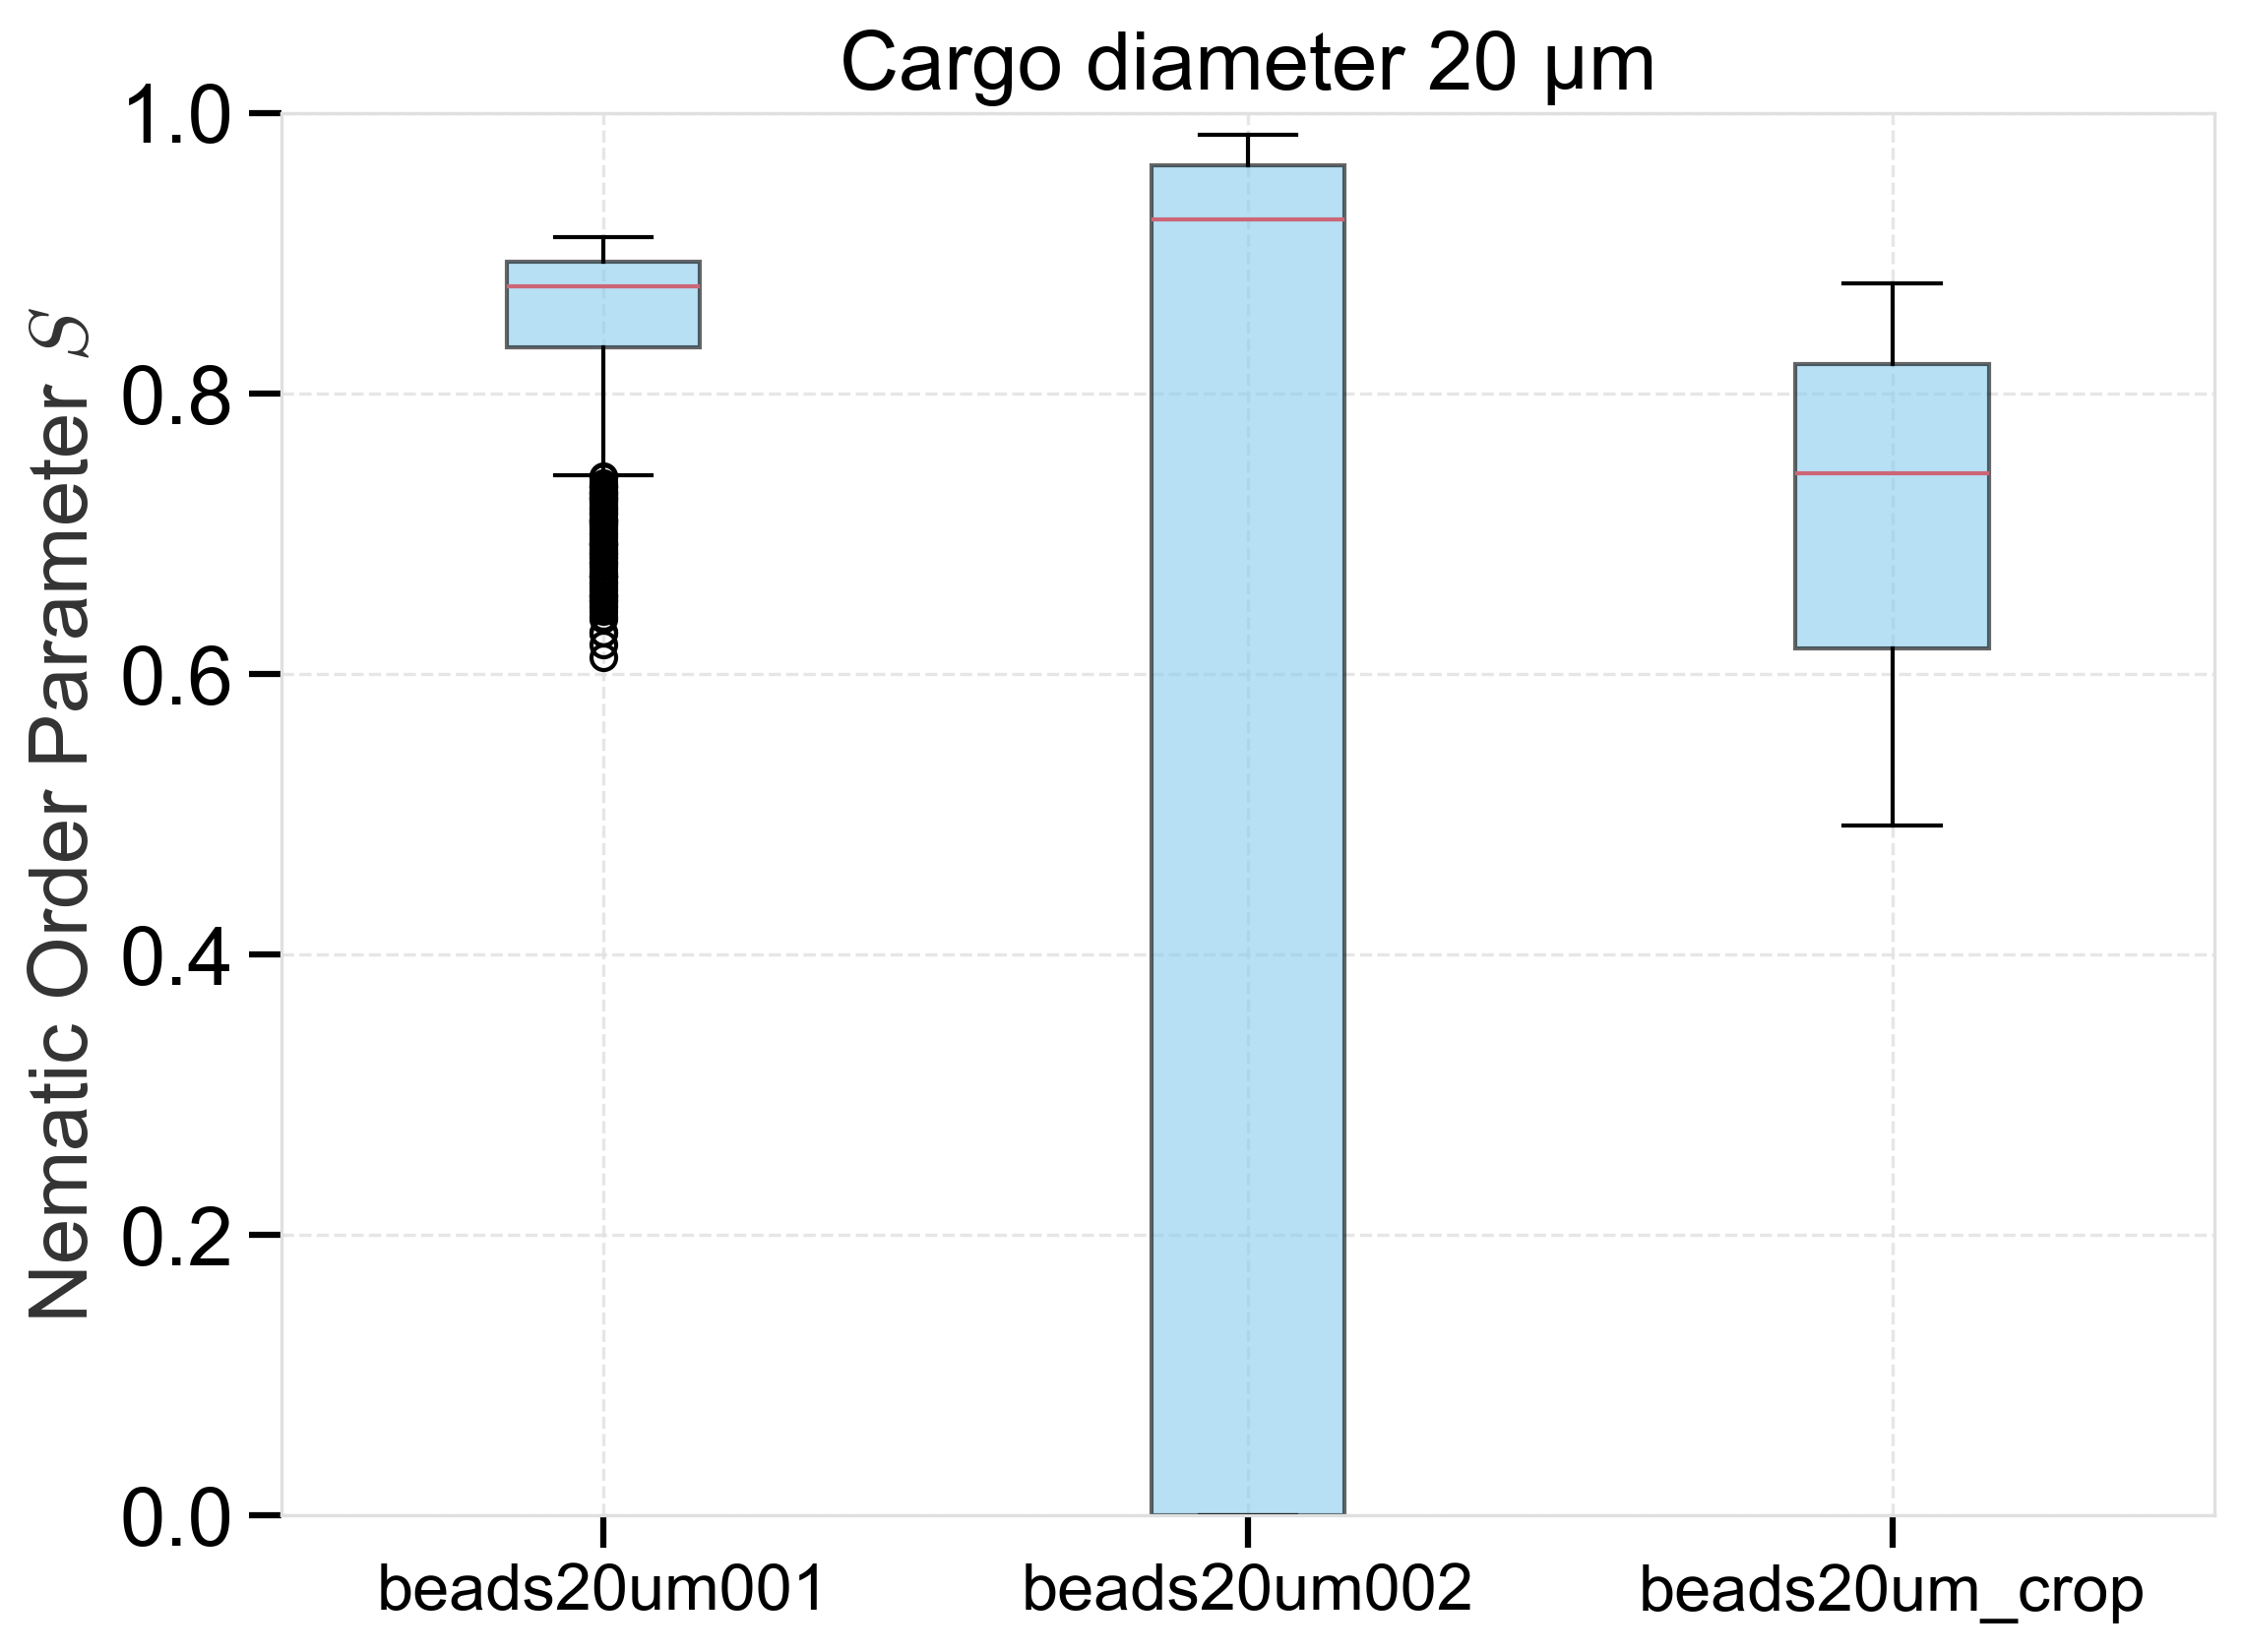

In [2]:
op_plot(mypass/"beads20um", cargo_diameter=20)